# Sub-Bytes
Loading data and importing libraries

In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [3]:
import pathlib
import pandas as pd
import numpy as np


FOLDER_PATH = pathlib.Path(".") / "sub_bytes"/ "sub_bytes_2"
OUTPUT_PATH = pathlib.Path(".") / "sub_bytes.csv"

try: 
    # Try to load the CSV File
    df = pd.read_csv(OUTPUT_PATH)
except FileNotFoundError:
    # Get all trace files in FOLDER_PATH
    trace_files = list(FOLDER_PATH.glob("*.txt"))

    # Create a dataframe with the trace files

    # Create a list of lists
    # Each list is a row in the dataframe
    # The first column is the secret value (analysed from the filename)
    # The rest of the colums are the instruction addresse

    data = []
    max_len = 0
    for trace_file in trace_files:
        # Get the secret value from the filename

        secret = int(trace_file.stem.split("_")[1])
        # Read the trace file
        with open(trace_file, "r") as f:
            trace = [int(x, 16) for x in f.read().splitlines()]
        # Add the secret value and the trace to the list of lists
        max_len = max(max_len, len(trace))
        data.append([trace_file.name, secret] + trace)

    # Create the dataframe
    df = pd.DataFrame(data, columns=["trace_file", "secret"] + [f"mem{i}" for i in range(max_len)])

    df.to_csv(OUTPUT_PATH, index = False)


# Data Description
The data is collected by setting a **secret** key and running the program with that secret key. During program execution all Memory accesses **mem-XX** are collected. In total that is 86 memory accesses during the whole execution.

The **secret** key is a randomly chosen value between 0 and $2^{64} = 18446744073709551616$

Since the program has 8 key-dependent lookups, we expect 8 memory accesses to be dependent on the secret.
Given that the lookup is an standard array-lookup, we expect a linear relationship between the **secret** and the 8 Memory accesses **memX1, memX2, ..., memX8**.

The relationship should be as following:

$secret = (a_0 \cdot memX1 + b_0) + (a_1 \cdot memX2 + b_1) + \dots$

## Approach
The goal is to find the dependent memory accesses **memX1, memX2, ..., memX8** and the parameters $a_0, a_1, \dots, b_0, b_1, \dots$

Using the features **mem0 - mem85** we want to find which features are correlated to the secret.

To do that we apply a *Linear Regression* Model, using a train-test split of 800-200.

The model should automatically detect the correlations and give us accurate predition on the 200 test secrets.

In [4]:
df.head()

,trace_file,secret,mem0,mem1,mem2,mem3,mem4,mem5,mem6,mem7,...,mem76,mem77,mem78,mem79,mem80,mem81,mem82,mem83,mem84,mem85
0,trace_10000369368611929355.txt,10000369368611929355,5670672,5670648,5670668,5670668,5670648,5670666,5670666,4276267,...,5670666,4276394,5670667,5670648,5670648,5670668,5670668,5670668,5670672,5670680
1,trace_10000530007239268649.txt,10000530007239268649,5670672,5670648,5670668,5670668,5670648,5670666,5670666,4276297,...,5670666,4276394,5670667,5670648,5670648,5670668,5670668,5670668,5670672,5670680
2,trace_10000664852027228354.txt,10000664852027228354,5670672,5670648,5670668,5670668,5670648,5670666,5670666,4276450,...,5670666,4276394,5670667,5670648,5670648,5670668,5670668,5670668,5670672,5670680
3,trace_10000875258175976375.txt,10000875258175976375,5670672,5670648,5670668,5670668,5670648,5670666,5670666,4276439,...,5670666,4276394,5670667,5670648,5670648,5670668,5670668,5670668,5670672,5670680
4,trace_10002101362539977763.txt,10002101362539977763,5670672,5670648,5670668,5670668,5670648,5670666,5670666,4276291,...,5670666,4276394,5670667,5670648,5670648,5670668,5670668,5670668,5670672,5670680


# Reversing
We are using a Linear regression which will automatically find the relevant memory columns and add them together.

Linear regression internally works with float64, which would introduce rounding errors because of our large secret. 
Therefore we split the Secret into the upper 32-bits and the lower 32-bits and join it together in the end

This means that a number like $10054330088175825702$ gets split into
* Upper bits: 2340956145
* Lower bits: 4030591782

since $2340956145 * 2^{32} + 4030591782 = 10054330088175825702$

This does not affect the model, and is just a workaround because of the internal implemenation of scikit-learn.

In [5]:
print(10054330088175825702 % (1 << 32) , 10054330088175825702 >> 32)

4030591782 2340956145


In [6]:
2340956145 * (2 ** 32) + 4030591782 == 10054330088175825702

True

In [7]:
X = df.iloc[:, 2:].values
y = df.iloc[:, 1].values
y_lower = y % (1 << 32)
y_upper = (y >> 32) % (1 << 32)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Split target value in lower and upper bits
y_lower_train = y_train % (1 << 32)
y_upper_train = (y_train >> 32) % (1 << 32)

# Predict lower bits
regressor = LinearRegression()
regressor.fit(X_train, y_lower_train)
y_lower_pred = regressor.predict(X_test).round().astype(np.uint64)

# Predict upper bits
regressor = LinearRegression()
regressor.fit(X_train, y_upper_train)
y_upper_pred = regressor.predict(X_test).round().astype(np.uint64)

# Join together
y_pred = (y_upper_pred * (1 << 32)) + y_lower_pred


In [9]:
correct = sum(y_pred == y_test)/len(y_test)
print(f"{correct * 100:.02f} Percent of the secrets were reversed correctly")

100.00 Percent of the secrets were reversed correctly


## Symbolic execution
The results are in subBytes_results.csv (and took around 20hours lol)

In [10]:
df = pd.read_csv("subBytes_result.csv", header=None)

df.columns = ["filename", "result"]
df.head(n = 10)

,filename,result
0,/home/goreil/spysgx/traces/sub_bytes_1/trace_9...,9009367547913688047
1,/home/goreil/spysgx/traces/sub_bytes_1/trace_1...,11478698587092284929
2,/home/goreil/spysgx/traces/sub_bytes_1/trace_1...,1438066405921618580
3,/home/goreil/spysgx/traces/sub_bytes_1/trace_4...,4424664326549472796
4,/home/goreil/spysgx/traces/sub_bytes_1/trace_1...,16802199084700449176
5,/home/goreil/spysgx/traces/sub_bytes_1/trace_1...,14574058148577264727
6,/home/goreil/spysgx/traces/sub_bytes_1/trace_9...,9466134467976816724
7,/home/goreil/spysgx/traces/sub_bytes_1/trace_8...,8594594829896249617
8,/home/goreil/spysgx/traces/sub_bytes_1/trace_9...,9219329541772945041
9,/home/goreil/spysgx/traces/sub_bytes_1/trace_9...,9338674384430385556


In [11]:
df['secret'] = df.filename.str[45:-4]
df = df.astype({"secret": "uint64"})
df.head()

,filename,result,secret
0,/home/goreil/spysgx/traces/sub_bytes_1/trace_9...,9009367547913688047,9009367547913688047
1,/home/goreil/spysgx/traces/sub_bytes_1/trace_1...,11478698587092284929,11478698587092284929
2,/home/goreil/spysgx/traces/sub_bytes_1/trace_1...,1438066405921618580,1438066405921618580
3,/home/goreil/spysgx/traces/sub_bytes_1/trace_4...,4424664326549472796,4424664326549472796
4,/home/goreil/spysgx/traces/sub_bytes_1/trace_1...,16802199084700449176,16802199084700449176


In [12]:
correct = sum(df.result == df.secret)/len(df)
print(f"{correct * 100:.02f} Percent of the secrets were reversed correctly")

100.00 Percent of the secrets were reversed correctly


## Visualization
We can see in the valley that we have exactly 8 memory access matching the 8 bytes.

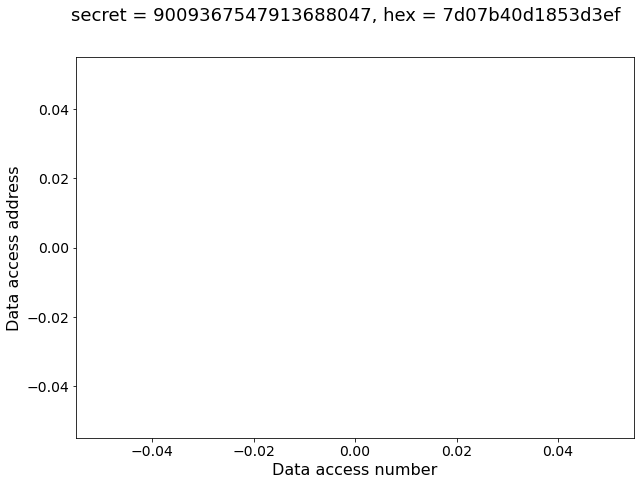

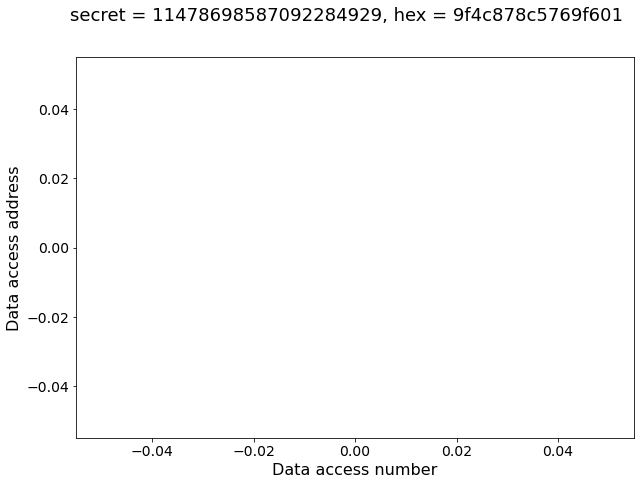

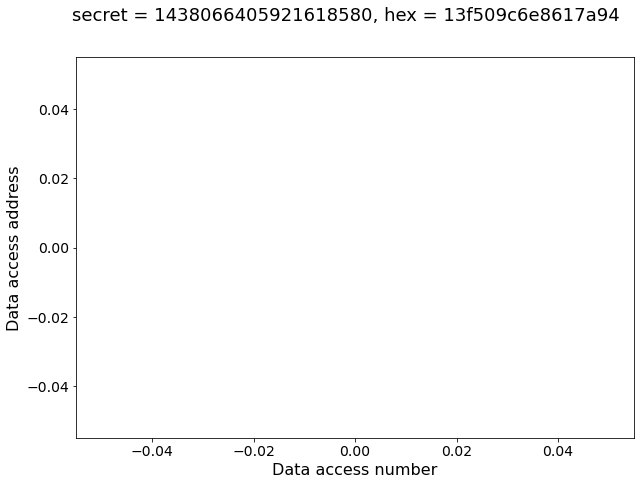

In [13]:
# Show example traces
with plt.style.context('./arend.mplstyle'):
    for i in range(3):
        _, secret, *traces = df.loc[i].to_list()[:-1]
        fig, ax = plt.subplots()
        ax.plot(traces)
        ax.set_xlabel("Data access number")
        ax.set_ylabel("Data access address")
        fig.suptitle(f"secret = {secret}, hex = {secret:08x}", size = 18)

In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  1002 non-null   object
 1   result    1002 non-null   uint64
 2   secret    1002 non-null   uint64
dtypes: object(1), uint64(2)
memory usage: 23.6+ KB
